In [1]:
import os
from functools import lru_cache

import pandas as pd
import numpy as np
from scipy.interpolate import RectBivariateSpline
import matplotlib.pyplot as plt
from astropy.io import fits

In [3]:
# SALT3 template0 (rest-frame SED grid: phase, wavelength [A], flux)
SALT3_MODEL_DIR = os.path.join(os.environ["SNDATA_ROOT"], "models", "SALT3", "SALT3.P22-NIR")
SALT3_TEMPLATE0_FILE = os.path.join(SALT3_MODEL_DIR, "salt3_template_0.dat.gz")

# Roman filter transmissions: nominal + per-SCA "shifted" (chromatic) bandpasses
ROMAN_FILTERS_DIR = "/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/ROMAN_FILTERS"

In [4]:
@lru_cache(maxsize=None)
def load_salt3_template(component):
    """Load salt3_template_{component}.dat.gz (component 0 or 1) into (phases, waves, flux_grid)."""
    path = os.path.join(SALT3_MODEL_DIR, f"salt3_template_{component}.dat.gz")
    phase, wave, flux = np.loadtxt(path, unpack=True)
    phases = np.unique(phase)
    waves = np.unique(wave)
    return phases, waves, flux.reshape(len(phases), len(waves))


def sed_components_at_epoch(epoch):
    """Rest-frame (wavelength [A], M0, M1) of the SALT3 templates at the given phase (days from peak)."""
    phases0, waves0, grid0 = load_salt3_template(0)
    phases1, waves1, grid1 = load_salt3_template(1)
    m0 = RectBivariateSpline(phases0, waves0, grid0, kx=1, ky=1)(epoch, waves0)[0]
    m1 = RectBivariateSpline(phases1, waves1, grid1, kx=1, ky=1)(epoch, waves1)[0]
    return waves0, m0, m1

In [5]:
def _parse_salt3_info_colorlaw(info_path):
    """Parse RESTLAMBDA_RANGE/COLORCOR_PARAMS out of a SALT3.INFO file."""
    with open(info_path) as f:
        for line in f:
            if line.strip().startswith("COLORCOR_PARAMS:"):
                vals = line.split(":", 1)[1].split()
                wave_lo, wave_hi, n = float(vals[0]), float(vals[1]), int(vals[2])
                coeffs = np.array([float(v) for v in vals[3:3 + n]])
                return wave_lo, wave_hi, coeffs
    raise ValueError(f"COLORCOR_PARAMS not found in {info_path}")


SALT3_INFO_FILE = os.path.join(SALT3_MODEL_DIR, "SALT3.INFO")
CL_WAVE_LO, CL_WAVE_HI, CL_COEFFS = _parse_salt3_info_colorlaw(SALT3_INFO_FILE)

# SALT2/SALT3 color law is defined in reduced wavelength l = (wave - B)/(V - B)
SALT2_B_WAVELENGTH = 4302.57
SALT2_V_WAVELENGTH = 5428.55

In [6]:
def _color_law_poly(l, coeffs):
    """SALT2/SALT3 color-law polynomial P(l): P(0)=0, P(1)=-1 by construction."""
    val = -l
    for i, p in enumerate(coeffs):
        val = val + p * (l - l ** (i + 2))
    return val


def _color_law_poly_deriv(l, coeffs):
    d = -1.0
    for i, p in enumerate(coeffs):
        d = d + p * (1 - (i + 2) * l ** (i + 1))
    return d


def salt3_color_law(wave):
    """
    SALT2/SALT3 color law CL(wave). The color-dependent flux factor is
    10 ** (-0.4 * c * CL(wave)). Linearly extrapolated outside
    [CL_WAVE_LO, CL_WAVE_HI] using the polynomial's value/derivative at the boundary.
    """
    wave = np.atleast_1d(np.asarray(wave, dtype=float))
    l = (wave - SALT2_B_WAVELENGTH) / (SALT2_V_WAVELENGTH - SALT2_B_WAVELENGTH)
    l_lo = (CL_WAVE_LO - SALT2_B_WAVELENGTH) / (SALT2_V_WAVELENGTH - SALT2_B_WAVELENGTH)
    l_hi = (CL_WAVE_HI - SALT2_B_WAVELENGTH) / (SALT2_V_WAVELENGTH - SALT2_B_WAVELENGTH)
    p_lo, p_hi = _color_law_poly(l_lo, CL_COEFFS), _color_law_poly(l_hi, CL_COEFFS)
    dp_lo, dp_hi = _color_law_poly_deriv(l_lo, CL_COEFFS), _color_law_poly_deriv(l_hi, CL_COEFFS)

    return np.where(
        l < l_lo, p_lo + dp_lo * (l - l_lo),
        np.where(l > l_hi, p_hi + dp_hi * (l - l_hi), _color_law_poly(l, CL_COEFFS)),
    )


def salt3_flux(epoch, x0=1.0, x1=0.0, c=0.0):
    """Rest-frame SALT3 SED: x0 * (M0 + x1*M1) * 10**(-0.4*c*CL(wave))."""
    wave, m0, m1 = sed_components_at_epoch(epoch)
    flux = x0 * (m0 + x1 * m1) * 10.0 ** (-0.4 * c * salt3_color_law(wave))
    return wave, flux

In [7]:
from scipy.optimize import least_squares


def fit_x1_color(spectrum_wave, spectrum_flux, epoch, x0_guess=1.0):
    """
    Fit (x0, x1, c) of the SALT3 model to a rest-frame flux-calibrated spectrum at `epoch`.

    spectrum_wave, spectrum_flux : rest-frame wavelength [A] and flux density of the SN spectrum.
    epoch : rest-frame phase (days from peak) the spectrum was taken at.
    """
    model_wave, m0, m1 = sed_components_at_epoch(epoch)
    m0_on_spec = np.interp(spectrum_wave, model_wave, m0)
    m1_on_spec = np.interp(spectrum_wave, model_wave, m1)
    cl_on_spec = salt3_color_law(spectrum_wave)

    def residuals(params):
        x0, x1, c = params
        model = x0 * (m0_on_spec + x1 * m1_on_spec) * 10.0 ** (-0.4 * c * cl_on_spec)
        return model - spectrum_flux

    result = least_squares(residuals, x0=[x0_guess, 0.0, 0.0])
    x0, x1, c = result.x
    return {"x0": x0, "x1": x1, "c": c, "success": result.success, "cost": result.cost}

In [8]:
def get_transmission_file(band, sca=None):
    """
    Path to a Roman transmission file for `band` (e.g. "F062", "F087", "F106",
    "F129", "F158", "F184", "W146", "F213").

    sca=None -> the nominal/reference bandpass: ROMAN_FILTERS/{band}/ROMAN_{band}.dat
                (falls back to ROMAN_FILTERS/ROMAN_{band}.dat for bands with no per-SCA files).
    sca=<int in 1..18> -> the SCA-specific "shifted" (chromatic) bandpass:
                ROMAN_FILTERS/{band}/ROMAN_{band}_shifted_{sca}.dat
    """
    band_dir = os.path.join(ROMAN_FILTERS_DIR, band)
    if sca is None:
        in_band_dir = os.path.join(band_dir, f"ROMAN_{band}.dat")
        return in_band_dir if os.path.exists(in_band_dir) else os.path.join(ROMAN_FILTERS_DIR, f"ROMAN_{band}.dat")
    return os.path.join(band_dir, f"ROMAN_{band}_shifted_{sca}.dat")


def load_transmission(path):
    """Load a transmission file: two columns, wavelength [A] and throughput (0-1).

    Header lines are skipped whether or not they start with '#' (nominal files are
    inconsistent about this), so parsing just skips any line that isn't two floats.
    """
    wave, thru = [], []
    with open(path) as f:
        for line in f:
            parts = line.split()
            if len(parts) != 2:
                continue
            try:
                w, t = float(parts[0]), float(parts[1])
            except ValueError:
                continue
            wave.append(w)
            thru.append(t)
    return np.array(wave), np.array(thru)

In [9]:
def synphot_mag(wave, flux, band_wave, band_thru):
    """
    Synthetic magnitude of an SED (wave [A], flux [erg/s/cm2/A]) through a bandpass.

    Only the *difference* between two such magnitudes is used in `handshake`, so any
    fixed zeropoint convention works as long as it's applied consistently.
    """
    thru_on_sed_grid = np.interp(wave, band_wave, band_thru, left=0.0, right=0.0)
    bandflux = np.trapezoid(flux * thru_on_sed_grid * wave, wave)
    return -2.5 * np.log10(bandflux)

In [10]:
def handshake(band, sca, epoch, z, x1=0.0, c=0.0):
    """Takes in given parameters and returns magcorrection.

    correction = mag(through SCA-specific transmission) - mag(through nominal transmission),
    evaluated on the SALT3 SED (M0 + x1*M1, color law c) at `epoch` (days from peak),
    redshifted to `z`.
    """
    rest_wave, rest_flux = salt3_flux(epoch, x1=x1, c=c)

    obs_wave = rest_wave * (1.0 + z)
    obs_flux = rest_flux / (1.0 + z)  # cosmological surface-brightness dimming

    nominal_wave, nominal_thru = load_transmission(get_transmission_file(band, sca=None))
    chromatic_wave, chromatic_thru = load_transmission(get_transmission_file(band, sca=sca))

    mag_nominal = synphot_mag(obs_wave, obs_flux, nominal_wave, nominal_thru)
    mag_chromatic = synphot_mag(obs_wave, obs_flux, chromatic_wave, chromatic_thru)

    return mag_chromatic - mag_nominal

In [11]:
handshake("F129", 10, epoch=+10.0, z=1)

np.float64(0.001403275575867724)

In [12]:
# Fit SN with nominal filters warp with x1, c
# x1 and c models, add ons to M0

# Sanity check: use template0 itself (x1=0, c=0) as a mock "observed" spectrum at a given
# epoch, and confirm fit_x1_color recovers x0=1, x1=0, c=0.
_test_epoch = 0.0
_test_wave, _test_m0, _ = sed_components_at_epoch(_test_epoch)
fit_x1_color(_test_wave, _test_m0, _test_epoch)

{'x0': np.float64(1.0),
 'x1': np.float64(0.0),
 'c': np.float64(0.0),
 'success': True,
 'cost': np.float64(0.0)}

In [13]:
# Full pipeline: fit (x1, c) from a spectrum, then feed them into the chromatic correction.
# Swap _test_wave/_test_m0/_test_epoch above for a real observed spectrum + its phase.
_fit = fit_x1_color(_test_wave, _test_m0, _test_epoch)
handshake("F129", 10, epoch=_test_epoch, z=1.0, x1=_fit["x1"], c=_fit["c"])

np.float64(0.0016420042698150894)

In [14]:
handshake("F184", 10, epoch=1, z=2.0, x1=_fit["x1"], c=_fit["c"])

np.float64(0.001004214292972705)

In [15]:
# Read in sim outputs

In [16]:
DATA_DIR = "/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/handshaker"


def load_lcplot(path):
    """Load a SNANA LCPLOT(text:csv) table into a DataFrame."""
    df = pd.read_csv(path, skipinitialspace=True)
    df.columns = [c.strip() for c in df.columns]
    return df


lcplot_s1 = load_lcplot(os.path.join(DATA_DIR, "CODETEST_HANDSHAKER_S1.LCPLOT.TEXT"))
lcplot_s2 = load_lcplot(os.path.join(DATA_DIR, "CODETEST_HANDSHAKER_S2.LCPLOT.TEXT"))

In [17]:
def load_fitres(path):
    """Load a SNANA FITRES text table (VARNAMES:/SN: rows, not plain CSV) into a DataFrame."""
    names, rows = None, []
    with open(path) as f:
        for line in f:
            if line.startswith("VARNAMES:"):
                names = line.split()[1:]
            elif line.startswith("SN:"):
                rows.append(line.split()[1:])
    df = pd.DataFrame(rows, columns=names)
    for col in df.columns:
        converted = pd.to_numeric(df[col], errors="coerce")
        if converted.notna().all():
            df[col] = converted
    return df


fitres_s1 = load_fitres(os.path.join(DATA_DIR, "CODETEST_HANDSHAKER_S1.FITRES.TEXT"))
fitres_s2 = load_fitres(os.path.join(DATA_DIR, "CODETEST_HANDSHAKER_S2.FITRES.TEXT"))

In [18]:
fitres_s2[["CID", "x1", "c", "mB"]].head()

,CID,x1,c,mB
0,1341390,0.37555,0.086097,26.61547
1,136357,0.60081,-0.060991,26.61911
2,1368244,0.75667,0.120720,24.36025
3,716809,0.63488,-0.018616,25.20539
4,2745016,0.57786,0.174840,26.92785


In [19]:
# CID alone isn't a unique key here (many epochs/bands per SN). DATAFLAG also has to be
# part of the key: a handful of epochs have both a DATAFLAG=1 (data) row and a DATAFLAG=0
# (model-grid) row at the exact same MJD/BAND, and merging on (CID, MJD, BAND) alone lets
# a data row in one file spuriously match a model-grid row in the other.
lcplot_data = pd.merge(lcplot_s1, lcplot_s2, on=["CID", "MJD", "BAND", "DATAFLAG"], how="inner", suffixes=("_s1", "_s2"))
lcplot_data["delta_FLUXCAL"] = lcplot_data["FLUXCAL_s2"] - lcplot_data["FLUXCAL_s1"]
lcplot_data["delta_SIM_FLUXCAL"] = lcplot_data["SIM_FLUXCAL_s2"] - lcplot_data["SIM_FLUXCAL_s1"]

In [20]:
fitres_data = pd.merge(fitres_s1, fitres_s2, on="CID", how="inner", suffixes=("_s1", "_s2"))
fitres_data["delta_x1"] = fitres_data["x1_s2"] - fitres_data["x1_s1"]
fitres_data["delta_c"] = fitres_data["c_s2"] - fitres_data["c_s1"]
fitres_data[["CID", "x1_s1", "x1_s2", "delta_x1", "c_s1", "c_s2", "delta_c"]]

/tmp/ipykernel_19635/2580343405.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fitres_data["delta_x1"] = fitres_data["x1_s2"] - fitres_data["x1_s1"]
/tmp/ipykernel_19635/2580343405.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fitres_data["delta_c"] = fitres_data["c_s2"] - fitres_data["c_s1"]


,CID,x1_s1,x1_s2,delta_x1,c_s1,c_s2,delta_c
0,1341390,0.374830,0.375550,0.000720,0.086649,0.086097,-5.515000e-04
1,136357,0.583330,0.600810,0.017480,-0.061135,-0.060991,1.437000e-04
2,1368244,0.758160,0.756670,-0.001490,0.121150,0.120720,-4.300000e-04
3,716809,0.636760,0.634880,-0.001880,-0.018332,-0.018616,-2.831000e-04
4,2745016,0.572660,0.577860,0.005200,0.176300,0.174840,-1.460000e-03
5,1793194,0.272600,0.269410,-0.003190,0.112560,0.113470,9.100000e-04
6,56221,-0.460924,-0.454190,0.006734,0.041568,0.042323,7.554000e-04
7,2765467,0.061331,0.070510,0.009179,-0.001742,-0.002516,-7.736200e-04
8,983926,0.712380,0.711670,-0.000710,0.018150,0.017862,-2.881000e-04
9,2838252,0.900700,0.894880,-0.005820,-0.142362,-0.142444,-8.200000e-05


In [21]:
print(f"delta_x1: mean={fitres_data['delta_x1'].mean():.4f}, std={fitres_data['delta_x1'].std():.4f}")
print(f"delta_c:  mean={fitres_data['delta_c'].mean():.5f}, std={fitres_data['delta_c'].std():.5f}")

# DATAFLAG: 1=>real data, 0=>fit-model curve (dense plotting grid), -1=>data rejected in fit.
real_data = lcplot_data[lcplot_data["DATAFLAG"] == 1]
print(f"\nmatched real-data epochs: {len(real_data)} of {len(lcplot_s1[lcplot_s1.DATAFLAG == 1])}")
real_data[["CID", "MJD", "BAND", "FLUXCAL_s1", "FLUXCAL_s2", "delta_FLUXCAL"]]

delta_x1: mean=0.0045, std=0.0209
delta_c:  mean=-0.00018, std=0.00110

matched real-data epochs: 293 of 293


,CID,MJD,BAND,FLUXCAL_s1,FLUXCAL_s2,delta_FLUXCAL
1,1341390,62483.0781,t,35.571,35.571,0.000
2,1341390,62563.2891,t,42.401,42.401,0.000
3,1341390,62573.9766,t,21.692,21.692,0.000
5,1341390,62491.4180,u,16.660,16.434,-0.226
6,1341390,62526.9805,u,172.360,171.490,-0.870
...,...,...,...,...,...,...
4516,2745016,62683.1484,O,164.390,164.390,0.000
4517,2745016,62740.5508,O,68.343,68.244,-0.099
4518,2745016,62683.1328,P,153.600,153.600,0.000
4519,2745016,62759.4844,P,77.583,77.264,-0.319


In [22]:
# Compare S1-vs-S2 delta to the theoretical handshake() prediction.
#
# The band-chars in FITRES/LCPLOT ("a", "b", ... "0", "1") don't map cleanly by index to
# ROMAN_FILTERS/*_shifted_N.dat (checked: transmission centroids don't line up 1:1 with
# SCA number). Instead, use the *exact* per-band-char transmission curves embedded in the
# two kcor files actually used by the fits: roman_nominal.fits (S1) and roman_shifts.fits (S2).
KCOR_NOMINAL_FILE = "/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/inputs/roman_nominal.fits"
KCOR_SHIFTS_FILE = "/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/inputs/roman_shifts.fits"


def _load_kcor_filtertrans(kcor_path):
    """Read the FilterTrans table of a kcor FITS file into plain numpy arrays."""
    with fits.open(kcor_path) as hdul:
        data = hdul["FilterTrans"].data
        wave = np.array(data["wavelength (A)"], dtype=float)
        cols = {name: np.array(data[name], dtype=float) for name in data.columns.names if name != "wavelength (A)"}
    return wave, cols


@lru_cache(maxsize=None)
def _kcor_filtertrans_cached(kcor_path):
    return _load_kcor_filtertrans(kcor_path)


def load_kcor_transmission(kcor_path, band_char):
    """Transmission curve for a single-char band (e.g. "a", "T") from a kcor FITS file's FilterTrans table."""
    wave, cols = _kcor_filtertrans_cached(kcor_path)
    matches = [name for name in cols if name.endswith(f"/{band_char}")]
    if len(matches) != 1:
        raise ValueError(f"expected exactly one column ending in '/{band_char}' in {kcor_path}, got {matches}")
    return wave, cols[matches[0]]

In [23]:
def handshake_kcor(band_char, epoch, z, x1=0.0, c=0.0):
    """
    Like handshake(), but for a single-char FITRES/LCPLOT band, using the exact
    transmission curves embedded in the S1/S2 kcor files rather than an SCA-numbered
    ROMAN_FILTERS file.

    correction = mag(S2 kcor transmission) - mag(S1 kcor transmission)
    """
    rest_wave, rest_flux = salt3_flux(epoch, x1=x1, c=c)
    obs_wave = rest_wave * (1.0 + z)
    obs_flux = rest_flux / (1.0 + z)

    nominal_wave, nominal_thru = load_kcor_transmission(KCOR_NOMINAL_FILE, band_char)
    shifts_wave, shifts_thru = load_kcor_transmission(KCOR_SHIFTS_FILE, band_char)

    mag_nominal = synphot_mag(obs_wave, obs_flux, nominal_wave, nominal_thru)
    mag_shifts = synphot_mag(obs_wave, obs_flux, shifts_wave, shifts_thru)

    return mag_shifts - mag_nominal

In [24]:
# Per-epoch comparison: empirical delta_mag (from FLUXCAL_s1/s2) vs. handshake_kcor's
# theoretical prediction, using each SN's S1-fitted (x1, c) and zHD, at that epoch's
# rest-frame phase (Trest = Tobs_s1 / (1+z)).
comparison = real_data.copy()
comparison = comparison.join(fitres_s1.set_index("CID")[["zHD", "x1", "c"]], on="CID")
comparison["Trest"] = comparison["Tobs_s1"] / (1.0 + comparison["zHD"])

positive_flux = (comparison["FLUXCAL_s1"] > 0) & (comparison["FLUXCAL_s2"] > 0)
print(f"dropping {(~positive_flux).sum()} of {len(comparison)} epochs with non-positive FLUXCAL (can't take log)")
comparison = comparison[positive_flux]

comparison["empirical_delta_mag"] = -2.5 * np.log10(comparison["FLUXCAL_s2"] / comparison["FLUXCAL_s1"])
comparison["predicted_delta_mag"] = [
    handshake_kcor(row.BAND, row.Trest, row.zHD, x1=row.x1, c=row.c) for row in comparison.itertuples()
]
comparison["residual"] = comparison["empirical_delta_mag"] - comparison["predicted_delta_mag"]

print(f"\nresidual (empirical - predicted): mean={comparison['residual'].mean():.4f}, std={comparison['residual'].std():.4f}")
print(f"correlation: {comparison['empirical_delta_mag'].corr(comparison['predicted_delta_mag']):.3f}")
comparison[["CID", "MJD", "BAND", "Trest", "empirical_delta_mag", "predicted_delta_mag", "residual"]]

dropping 9 of 293 epochs with non-positive FLUXCAL (can't take log)

residual (empirical - predicted): mean=0.0042, std=0.0345
correlation: 0.299


,CID,MJD,BAND,Trest,empirical_delta_mag,predicted_delta_mag,residual
1,1341390,62483.0781,t,-14.237351,-0.000000,0.000000,-0.000000
2,1341390,62563.2891,t,14.380046,-0.000000,0.000000,-0.000000
3,1341390,62573.9766,t,18.189991,-0.000000,0.000000,-0.000000
5,1341390,62491.4180,u,-11.258602,0.014829,0.004337,0.010492
6,1341390,62526.9805,u,1.426946,0.005494,0.005388,0.000106
...,...,...,...,...,...,...,...
4516,2745016,62683.1484,O,-2.592274,-0.000000,-0.001205,0.001205
4517,2745016,62740.5508,O,17.326939,0.001574,0.000033,0.001541
4518,2745016,62683.1328,P,-2.599214,-0.000000,-0.003016,0.003016
4519,2745016,62759.4844,P,23.896115,0.004473,0.002481,0.001993


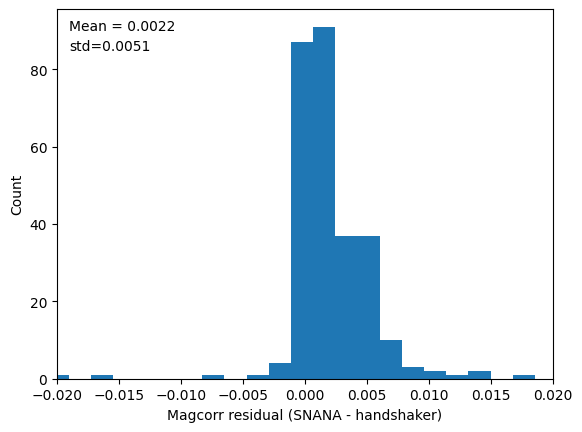

In [ ]:
comparison = comparison[comparison["residual"] < 0.2]
plt.hist(comparison["residual"], bins=40)
plt.xlabel("Magcorr residual (SNANA - handshaker)")
plt.text(-0.019, 90, f"Mean = {comparison['residual'].mean():.4f}")
plt.text(-0.019, 85, f"std={comparison['residual'].std():.4f}")

plt.xlim(-0.02, 0.02)
plt.ylabel("Count")

plt.savefig("magcor_residuals.png")

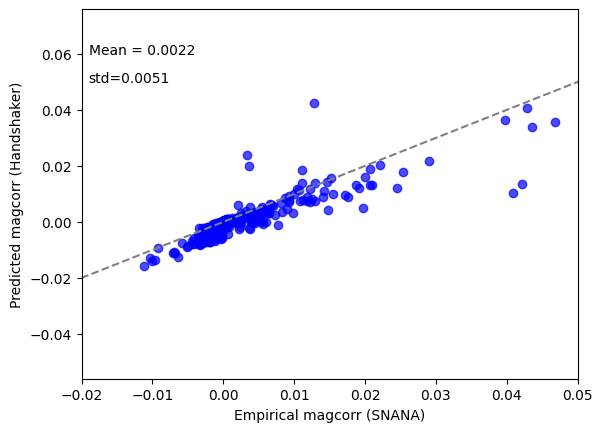

In [41]:
comparison = comparison[comparison["residual"] < 0.2]
plt.plot(comparison["empirical_delta_mag"], comparison["predicted_delta_mag"], ls="", marker="o", color="blue", alpha=0.7)
x = np.linspace(-0.05, 0.07, 1000)
y = x
plt.plot(x, y, ls="--", color="grey")
plt.xlabel("Magcorr residual (SNANA - handshaker)")

plt.text(-0.019, 0.06, f"Mean = {comparison['residual'].mean():.4f}")
plt.text(-0.019, 0.05, f"std={comparison['residual'].std():.4f}")


plt.xlim(-.02, 0.05)
plt.ylabel("Predicted magcorr (Handshaker)")
plt.xlabel("Empirical magcorr (SNANA)")
plt.savefig("handshaker_snana_scatter.png")

In [7]:
import numpy as np
from astropy.time import Time
from astropy.table import Table

cadence_start_date = Time('2026-09-12T00:00:00.0', format='isot', scale='utc')
decon_period = 20 # days

rate_mosaic_filename = '/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/handshaker/src/handshaker/data/ice_rate_mosaic.npz'
interim_T_filename = 'data/spectral_responses_SCA10.ecsv'

def ice_growth_rate(sca, pix_row_col):

    """Returns toy-model ice growth rate given an SCA number and
    position within it in pixel coordinates. i.e. x and y both in
    the 0-4096 range.

    Parameters
    ----------

    sca : int
      1-indexed FPA detector number (e.g. 2 for WFI02)
    pix_row_col : tuple
      the (y, x) position within the detector in pixel coordinates
    
    Returns
    -------

    The model ice growth rate in nm/day

    """

    dict = np.load(rate_mosaic_filename, allow_pickle=True)

    rate_mosaic = dict['rate_mosaic']
    det_row_offsets = dict['det_row_offsets'].item()
    det_col_offsets = dict['det_col_offsets'].item()
    pix_per_bin = dict['pix_per_bin'].item()

    yind = pix_row_col[0]//pix_per_bin + det_row_offsets[sca]
    xind = pix_row_col[1]//pix_per_bin + det_col_offsets[sca]

    return rate_mosaic[yind, xind]


def ice_thickness(sca, pix_row_col, time_mjd):

    """Returns toy-model ice thickness given an SCA number and
    position within it in pixel coordinate. i.e. x and y both in
    the 0-4096 range.

    Parameters
    ----------

    sca : int
      1-indexed FPA detector number (e.g. 2 for WFI02)
    pix_row_col : tuple
      the (y, x) position within the detector in pixel coordinates
    time_mjd : float
      MJD for which ice transmission is desired; must be no ealier
      than   The MJDs used must be no earlier than
      61295.0
    
    Returns
    -------

    The model ice thinkness in nm

    """

    time_since_decon = (time_mjd - cadence_start_date.mjd) % decon_period

    return ice_growth_rate(sca, pix_row_col)*time_since_decon


def ice_relative_transmission(sca, pix_row_col, time_mjd):

    """Returns toy-model ice transmission relative to epoch 0 given an
    SCA number and position within it in pixel coordinate. i.e. x and
    y both in the 0-4096 range.

    Parameters
    ----------

    sca : int
      1-indexed FPA detector number (e.g. 2 for WFI02)
    pix_row_col : tuple
      the (y, x) position within the detector in pixel coordinates
    time_mjd : float
      MJD for which ice transmission is desired; must be no ealier
      than   The MJDs used must be no earlier than
      61295.0
    
    Returns
    -------

    Two arrays: first is wavelength in nm; the second is transmission
    as a fraction relative to the transmission at epoch 0.

    and

    a scalar (float) which gives the ice layer thickness in nm 
    
    """

    tab = Table.read(interim_T_filename)
    colnames = tab.colnames
    tab_thicknesses = np.array([float(s[s.find('_d')+2:s.find('nm')]) for s in colnames if '_d' in s])
    want_thickness = ice_thickness(sca, pix_row_col, time_mjd)
    right_edgenum = np.digitize(want_thickness, tab_thicknesses)
    neighbor_tab_thicknesses = tab_thicknesses[right_edgenum-1:right_edgenum+1]
    # linear interpolation weights between neighboring passbands
    wt = np.abs(want_thickness - neighbor_tab_thicknesses) / np.diff(neighbor_tab_thicknesses)[0]
    passband = wt[1]*tab[tab.colnames[right_edgenum]] + wt[0]*tab[tab.colnames[right_edgenum+1]]

    return tab['wavelength'], passband, want_thickness


In [ ]:
dict = np.load(rate_mosaic_filename, allow_pickle=True)
rate_mosaic = dict['rate_mosaic']


plt.plot(rate_mosaic )



ModuleNotFoundError: No module named 'numpy._core'

In [9]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTDIR = "out/roman_polyfit"          # <-- your polyfit output dir
summary = pd.read_csv(os.path.join(OUTDIR, "polyfit_summary.csv"))
summary

,band,ice_thick_nm,sca,order,residual_rms,max_abs_residual,support_lo,support_hi,c0,c1,c2,c3,c4,c5,table_file
0,F062,30,10,5,6.426766e-03,4.109969e-02,4670.0,7810.0,0.946157,0.074014,0.409553,-0.437152,-0.357805,0.401947,polyfit_F062_d30nm.csv
1,F062,90,10,5,2.879267e-02,1.125728e-01,4670.0,7810.0,0.903894,0.493717,0.567919,-1.569884,-0.419525,1.118004,polyfit_F062_d90nm.csv
2,F062,150,10,5,1.470013e-02,4.493297e-02,4670.0,7810.0,0.998051,0.513600,-0.048994,-1.180901,0.082359,0.666692,polyfit_F062_d150nm.csv
3,F062,240,10,5,1.411757e-02,6.651403e-02,4670.0,7810.0,1.003414,0.120628,0.173527,-0.723739,-0.194772,0.598169,polyfit_F062_d240nm.csv
4,F062,300,10,5,2.672728e-02,1.015492e-01,4670.0,7810.0,0.907140,0.316095,0.395129,-1.193442,-0.275502,0.884704,polyfit_F062_d300nm.csv
5,F106,30,10,5,1.142495e-05,5.387561e-05,9020.0,12240.0,0.998055,0.018324,-0.001524,-0.008976,0.004367,-0.000386,polyfit_F106_d30nm.csv
6,F106,90,10,5,8.964635e-06,4.612625e-05,9020.0,12240.0,1.003329,0.051384,-0.021492,-0.015193,0.011881,-0.002424,polyfit_F106_d90nm.csv
7,F106,150,10,5,8.073487e-06,4.128973e-05,9020.0,12240.0,1.016899,0.062129,-0.047358,-0.009167,0.015371,-0.004068,polyfit_F106_d150nm.csv
8,F106,240,10,5,8.007223e-06,3.348562e-05,9020.0,12240.0,1.031328,0.028244,-0.058103,0.007324,0.012683,-0.005455,polyfit_F106_d240nm.csv
9,F106,300,10,5,1.020558e-05,4.254007e-05,9020.0,12240.0,1.026268,-0.000491,-0.042921,0.009120,0.009252,-0.004660,polyfit_F106_d300nm.csv


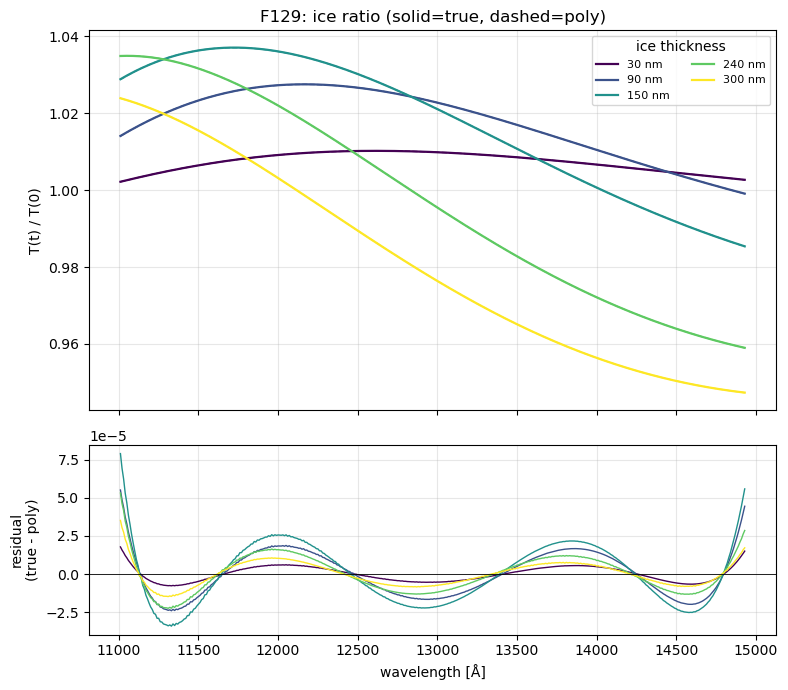

In [10]:
def plot_band(band, outdir=OUTDIR, summary=summary):
    g = summary[summary.band == band].sort_values("ice_thick_nm")
    colors = plt.cm.viridis(np.linspace(0, 1, max(len(g), 2)))
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 7),
                                   gridspec_kw={"height_ratios": [2, 1]})
    for c, (_, row) in zip(colors, g.iterrows()):
        df = pd.read_csv(os.path.join(outdir, row.table_file))
        ax1.plot(df.WAVE, df.RATIO_TRUE, color=c, lw=1.6, label=f"{row.ice_thick_nm:.0f} nm")
        ax1.plot(df.WAVE, df.RATIO_POLY, color=c, lw=1.0, ls="--")   # dashed = polynomial
        ax2.plot(df.WAVE, df.RESIDUAL, color=c, lw=1.0)
    ax1.set(ylabel="T(t) / T(0)", title=f"{band}: ice ratio (solid=true, dashed=poly)")
    ax1.legend(title="ice thickness", fontsize=8, ncol=2); ax1.grid(alpha=.3)
    ax2.axhline(0, color="k", lw=.6)
    ax2.set(ylabel="residual\n(true - poly)", xlabel="wavelength [Å]"); ax2.grid(alpha=.3)
    plt.tight_layout(); plt.show()

plot_band("F129")     # try F062 to see the polynomial break down

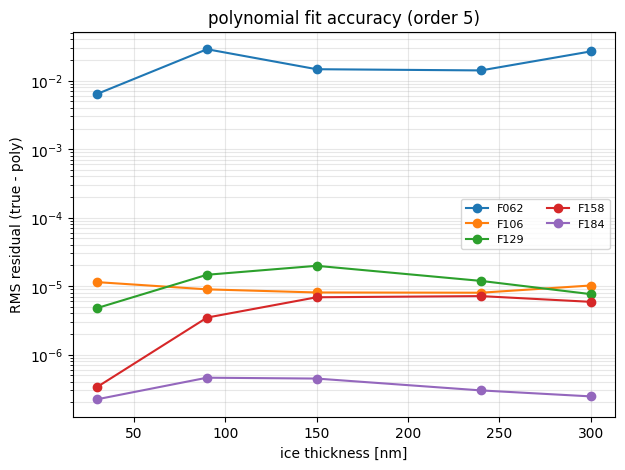

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
for band, gb in summary.groupby("band"):
    gb = gb.sort_values("ice_thick_nm")
    ax.plot(gb.ice_thick_nm, gb.residual_rms, marker="o", label=band)
ax.set(xlabel="ice thickness [nm]", ylabel="RMS residual (true - poly)", yscale="log",
       title=f"polynomial fit accuracy (order {int(summary.order.iloc[0])})")
ax.grid(alpha=.3, which="both"); ax.legend(ncol=2, fontsize=8)
plt.show()

In [1]:
import sys
sys.path.insert(0, "/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/handshaker_pkg/src")
from handshaker import get_filter, get_ice_model, bandpasses_on_grid, DEFAULT_GRID

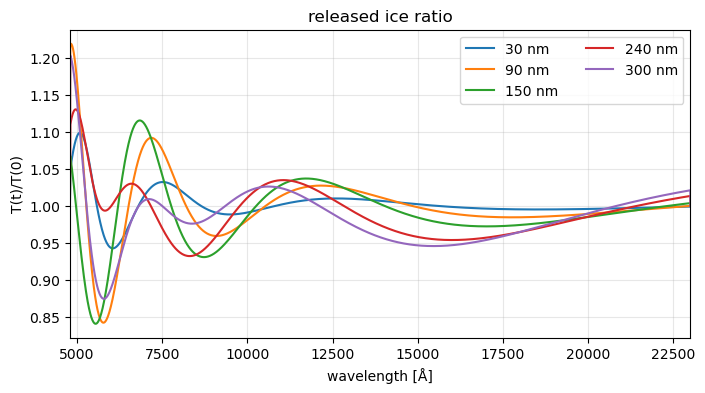

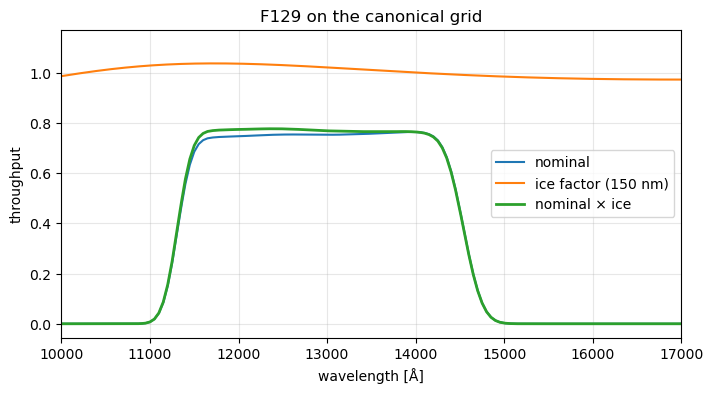

In [4]:
from handshaker import get_filter, get_ice_model, bandpasses_on_grid, DEFAULT_GRID

filters = get_filter("rujuta",
    root="/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/handshaker/ROMAN_FILTERS")
ice = get_ice_model("released")

# the released ice ratio itself, several thicknesses
g = DEFAULT_GRID
fig, ax = plt.subplots(figsize=(8, 4))
for t in [30, 90, 150, 240, 300]:
    ax.plot(g.wave, ice.relative_transmission(t).regrid(g), label=f"{t} nm")
ax.set(xlabel="wavelength [Å]", ylabel="T(t)/T(0)", xlim=(4800, 23000),
       title="released ice ratio"); ax.legend(ncol=2); ax.grid(alpha=.3); plt.show()

# nominal filter x ice, all aligned on the grid
bp = bandpasses_on_grid("F129", filters, ice, sca=10, thickness_nm=150.0)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bp.wave, bp.nominal, label="nominal")
ax.plot(bp.wave, bp.ice_factor, label="ice factor (150 nm)")
ax.plot(bp.wave, bp.nominal_x_ice, lw=2, label="nominal × ice")
ax.set(xlabel="wavelength [Å]", ylabel="throughput", xlim=(10000, 17000),
       title="F129 on the canonical grid"); ax.legend(); ax.grid(alpha=.3); plt.show()

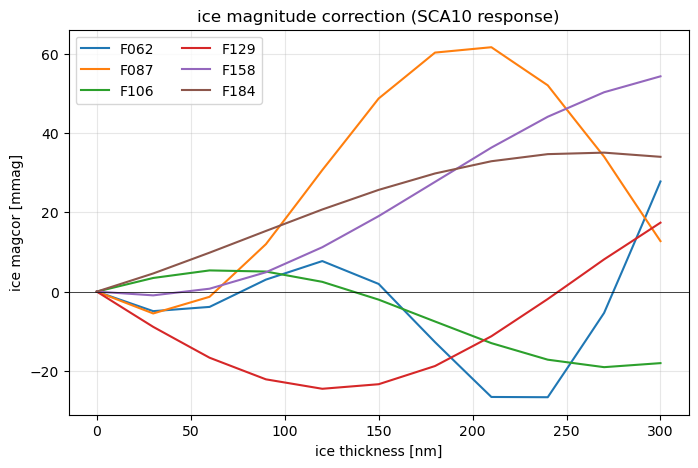

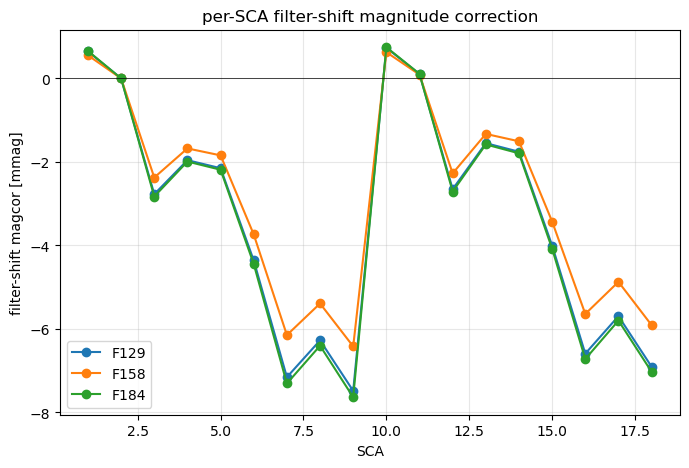

In [7]:
import numpy as np, matplotlib.pyplot as plt
from handshaker import get_filter, get_ice_model, synthetic_sed, compute_magcor, Observation

filters = get_filter("rujuta",
    root="/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/handshaker/ROMAN_FILTERS")
ice = get_ice_model("released")
sed = synthetic_sed()                 # swap for SALT3SEDModel(...) for a real SN SED

# (1) ICE magcorrection vs ice thickness, per band  -- Δmag you'd apply
thicks = np.linspace(0, 300, 31)
fig, ax = plt.subplots(figsize=(8, 5))
for band in ["F062", "F087", "F106", "F129", "F158", "F184"]:
    m = [compute_magcor(Observation(band=band, sca=10, ice_thickness_nm=t),
                        sed, filters, ice)["magcor_ice"] for t in thicks]
    ax.plot(thicks, 1e3*np.array(m), label=band)
ax.set(xlabel="ice thickness [nm]", ylabel="ice magcor [mmag]",
       title="ice magnitude correction (SCA10 response)")
ax.axhline(0, color="k", lw=.5); ax.legend(ncol=2); ax.grid(alpha=.3); plt.show()

# (2) FILTER-SHIFT magcorrection vs SCA (field-dependent chromatic effect), one band
scas = list(range(1, 19))
fig, ax = plt.subplots(figsize=(8, 5))
for band in ["F129", "F158", "F184"]:
    m = [compute_magcor(Observation(band=band, sca=s, ice_thickness_nm=0.0),
                        sed, filters, ice)["magcor_shift"] for s in scas]
    ax.plot(scas, 1e3*np.array(m), "o-", label=band)
ax.set(xlabel="SCA", ylabel="filter-shift magcor [mmag]",
       title="per-SCA filter-shift magnitude correction")
ax.axhline(0, color="k", lw=.5); ax.legend(); ax.grid(alpha=.3); plt.show()

In [2]:
import uproot, awkward as ak, numpy as np, matplotlib.pyplot as plt

f = uproot.open("tests/CODETEST_HANDSHAKER.root")
for name, cls in f.classnames().items():
    print(f"{name:30s} {cls}")

# pick the TTree whose name is SPECTRA (handles the ;1 cycle suffix / nesting)
spec_key = next(n for n, c in f.classnames().items()
                if "TTree" in c and n.split("/")[-1].split(";")[0] == "SPECTRA")
t = f[spec_key]
print("\nusing tree:", spec_key, "| entries:", t.num_entries)

MONINIT;1                      TDirectory
MONINIT/H00401;1               TH1F
MONINIT/H00402;1               TH1F
MONINIT/H00403;1               TH1F
MONINIT/H00404;1               TH1F
MONINIT/H00405;1               TH1F
MONINIT/H00406;1               TH1F
MONINIT/H00407;1               TH1F
MONINIT/H00408;1               TH1F
MONSN;1                        TDirectory
GLOBAL;1                       TTree
SNLCPAK;1                      TTree
SNANA;1                        TTree
FITRES;1                       TTree
SPECTRA;1                      TTree

using tree: SPECTRA;1 | entries: 30


In [3]:
for br, ty in t.typenames().items():
    print(f"  {br:28s} {ty}")

  CCID                         char*
  FIELD                        char*
  BAND                         char*
  DETNUM                       int32_t
  IMGNUM                       int32_t
  IFILTOBS                     int32_t
  MJD                          double
  TREST                        float
  LAMREST                      float
  FLUXCAL_DATA                 float
  FLUXCAL_DATA_ERR             float
  FLUXCAL_MODEL                float
  FLUXCAL_MODEL_ERR            float
  MAG_MODEL_R                  float
  MAG_MODEL_Z                  float
  MAG_MODEL_Y                  float
  MAG_MODEL_J                  float
  MAG_MODEL_H                  float
  MAG_MODEL_F                  float
  MAG_MODEL_ERR_R              float
  MAG_MODEL_ERR_Z              float
  MAG_MODEL_ERR_Y              float
  MAG_MODEL_ERR_J              float
  MAG_MODEL_ERR_H              float
  MAG_MODEL_ERR_F              float
  NBLAM                        int32_t
  SPEC_LAMLIST(NBLAM)        

In [4]:
ev = t.arrays()                     # reads all branches of THIS tree
print("fields:", ev.fields)
print("n spectra:", len(ev))

fields: ['CCID', 'FIELD', 'BAND', 'DETNUM', 'IMGNUM', 'IFILTOBS', 'MJD', 'TREST', 'LAMREST', 'FLUXCAL_DATA', 'FLUXCAL_DATA_ERR', 'FLUXCAL_MODEL', 'FLUXCAL_MODEL_ERR', 'MAG_MODEL_R', 'MAG_MODEL_Z', 'MAG_MODEL_Y', 'MAG_MODEL_J', 'MAG_MODEL_H', 'MAG_MODEL_F', 'MAG_MODEL_ERR_R', 'MAG_MODEL_ERR_Z', 'MAG_MODEL_ERR_Y', 'MAG_MODEL_ERR_J', 'MAG_MODEL_ERR_H', 'MAG_MODEL_ERR_F', 'NBLAM', 'SPEC_LAMLIST(NBLAM)', 'SPEC_FLUXLIST(NBLAM)']
n spectra: 30


len: 443 | range: 10790.0 - 15210.0 Å


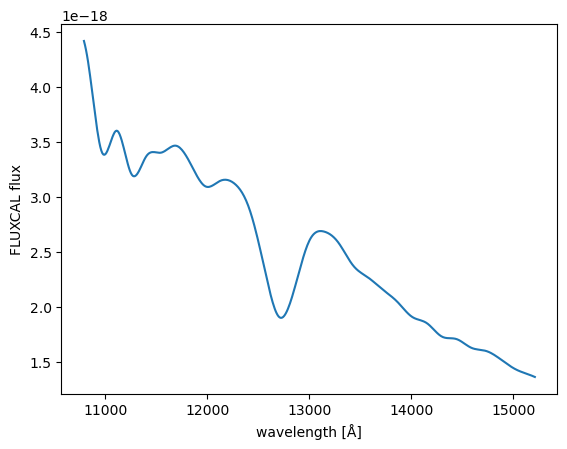

In [5]:
LAM = "SPEC_LAMLIST(NBLAM)"                 # <- set to the real names from ev.fields
FLX = "SPEC_FLUXLIST(NBLAM)"
i = 0
wave = ak.to_numpy(ev[LAM][i]); flux = ak.to_numpy(ev[FLX][i])
print("len:", len(wave), "| range:", wave.min(), "-", wave.max(), "Å")
plt.plot(wave, flux); plt.xlabel("wavelength [Å]"); plt.ylabel("FLUXCAL flux"); plt.show()

fields: ['CCID', 'FIELD', 'BAND', 'DETNUM', 'IMGNUM', 'IFILTOBS', 'MJD', 'TREST', 'LAMREST', 'FLUXCAL_DATA', 'FLUXCAL_DATA_ERR', 'FLUXCAL_MODEL', 'FLUXCAL_MODEL_ERR', 'MAG_MODEL_R', 'MAG_MODEL_Z', 'MAG_MODEL_Y', 'MAG_MODEL_J', 'MAG_MODEL_H', 'MAG_MODEL_F', 'MAG_MODEL_ERR_R', 'MAG_MODEL_ERR_Z', 'MAG_MODEL_ERR_Y', 'MAG_MODEL_ERR_J', 'MAG_MODEL_ERR_H', 'MAG_MODEL_ERR_F', 'NBLAM', 'SPEC_LAMLIST(NBLAM)', 'SPEC_FLUXLIST(NBLAM)']
array fields: ['SPEC_LAMLIST(NBLAM)', 'SPEC_FLUXLIST(NBLAM)']
LAM = SPEC_LAMLIST(NBLAM) | FLX = SPEC_FLUXLIST(NBLAM)
len: 443 | range: 10790.0 - 15210.0 Å


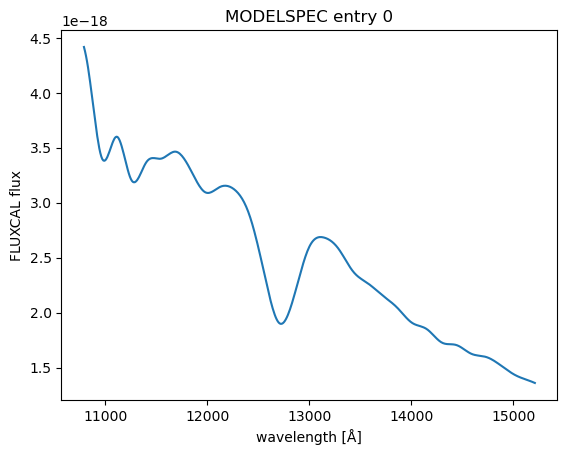

In [9]:
import uproot, awkward as ak, numpy as np, matplotlib.pyplot as plt
from handshaker import FixedSED, get_filter, get_ice_model, compute_magcor, Observation

f = uproot.open("tests/CODETEST_HANDSHAKER.root")
spec_key = next(n for n, c in f.classnames().items()
                if "TTree" in c and n.split("/")[-1].split(";")[0] == "SPECTRA")
ev = f[spec_key].arrays()
print("fields:", ev.fields)

# per-spectrum array fields = the ones whose first entry is a (non-string) sequence
arr_fields = [fld for fld in ev.fields
              if hasattr(ev[fld][0], "__len__") and not isinstance(ev[fld][0], str)]
print("array fields:", arr_fields)

i = 0
# wavelength = the monotonically increasing array; flux = the other
def is_wave(a):
    a = ak.to_numpy(a);  return a.size > 2 and np.all(np.diff(a) >= 0) and a.max() > 1000
LAM = next(fld for fld in arr_fields if is_wave(ev[fld][i]))
FLX = next(fld for fld in arr_fields if fld != LAM)
print("LAM =", LAM, "| FLX =", FLX)

wave = ak.to_numpy(ev[LAM][i]); flux = ak.to_numpy(ev[FLX][i])
print("len:", len(wave), "| range:", wave.min(), "-", wave.max(), "Å")
plt.plot(wave, flux); plt.xlabel("wavelength [Å]"); plt.ylabel("FLUXCAL flux")
plt.title(f"MODELSPEC entry {i}"); plt.show()

In [10]:
# --- bridge to handshaker: this MODELSPEC SED -> a magcor ---
filters = get_filter("rujuta",
    root="/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/handshaker/ROMAN_FILTERS")
ice = get_ice_model("released")
sed = FixedSED(wave, flux)
mjd = float(ev["MJD"][i]) if "MJD" in ev.fields else 0.0
obs = Observation(band="F129", sca=10, mjd=mjd, ice_thickness_nm=90.0, z=0.0)
print(compute_magcor(obs, sed, filters, ice))

{'ice_thickness': 90.0, 'magcor_shift_sn': np.float64(0.0004489355251067195), 'magcor_shift_star': 0.0, 'magcor_shift': np.float64(0.0004489355251067195), 'magcor_ice_sn': np.float64(-0.021987114405110475), 'magcor_ice_star': 0.0, 'magcor_ice': np.float64(-0.021987114405110475), 'magcor_total_sn': np.float64(-0.021504710390981785), 'magcor_total_star': 0.0, 'magcor_total': np.float64(-0.021504710390981785), 'lam_eff_nominal': np.float64(12805.818595520834), 'lam_eff_shifted': np.float64(12812.391488328862), 'wavecor': np.float64(6.572892808027973)}


In [ ]:
import uproot
f = uproot.open("tests/CODETEST_HANDSHAKER.root")
print("keys:", f.keys())
print("classnames:", f.classnames())

keys: ['MONINIT;1', 'MONINIT/H00401;1', 'MONINIT/H00402;1', 'MONINIT/H00403;1', 'MONINIT/H00404;1', 'MONINIT/H00405;1', 'MONINIT/H00406;1', 'MONINIT/H00407;1', 'MONINIT/H00408;1', 'MONSN;1', 'MONSN/SN2747770;1', 'MONSN/SN263515;1', 'MONSN/SN2356175;1', 'MONSN/SN2023923;1', 'GLOBAL;1', 'SNLCPAK;1', 'SNANA;1', 'FITRES;1', 'MODELSPEC;1']
classnames: {'MONINIT;1': 'TDirectory', 'MONINIT/H00401;1': 'TH1F', 'MONINIT/H00402;1': 'TH1F', 'MONINIT/H00403;1': 'TH1F', 'MONINIT/H00404;1': 'TH1F', 'MONINIT/H00405;1': 'TH1F', 'MONINIT/H00406;1': 'TH1F', 'MONINIT/H00407;1': 'TH1F', 'MONINIT/H00408;1': 'TH1F', 'MONSN;1': 'TDirectory', 'MONSN/SN2747770;1': 'TDirectory', 'MONSN/SN263515;1': 'TDirectory', 'MONSN/SN2356175;1': 'TDirectory', 'MONSN/SN2023923;1': 'TDirectory', 'GLOBAL;1': 'TTree', 'SNLCPAK;1': 'TTree', 'SNANA;1': 'TTree', 'FITRES;1': 'TTree', 'MODELSPEC;1': 'TTree'}


In [2]:
import pandas as pd
from handshaker import load_modelspec, magcor_table, get_filter, get_ice_model

spec = load_modelspec("/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/handshaker/tests/CODETEST_HANDSHAKER.root")

print(spec[["cid","band","band_raw","sca","mjd","trest","nlam"]].head())

filters = get_filter("rujuta",
    root="/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/handshaker/ROMAN_FILTERS")
ice = get_ice_model("released")

tbl = magcor_table(spec, filters, ice, reference_sca=2, ice_thickness_nm=90.0)
tbl.round(5).head(10)

       cid  band band_raw  sca         mjd      trest  nlam
0  2747770  F129        J    9  62630.0057  -7.154452   443
1  2747770  F087        Z   18  62640.8838  -1.931136   298
2  2747770  F106        Y   15  62651.1060   2.977237   363
3  2747770  F087        Z    7  62662.0101   8.213037   298
4  2747770  F129        J   16  62673.9263  13.934814   443


,cid,band,sca,mjd,trest,ice_thickness_nm,magcor_shift,magcor_ice,magcor_total,wavecor,lam_eff_ref,lam_eff_obs
0,2747770,F129,9,62630.0057,-7.15445,90.0,-0.00439,-0.02199,-0.02670,-66.94751,12805.81860,12738.87108
1,2747770,F087,18,62640.8838,-1.93114,90.0,0.00187,0.01785,0.01836,-31.34767,8718.95864,8687.61098
2,2747770,F106,15,62651.1060,2.97724,90.0,0.00012,0.00383,0.00469,-27.40291,10524.52572,10497.12281
3,2747770,F087,7,62662.0101,8.21304,90.0,0.00631,0.01907,0.02403,-33.83509,8770.09871,8736.26362
4,2747770,F129,16,62673.9263,13.93481,90.0,-0.01767,-0.02269,-0.04052,-60.19877,12725.88933,12665.69057
5,2747770,F106,6,62683.5176,18.54025,90.0,0.00469,-0.00013,0.00507,-19.94554,10642.45018,10622.50463
6,2747770,F129,9,62692.7996,22.99717,90.0,-0.01525,-0.02202,-0.03750,-64.95425,12783.62997,12718.67573
7,2747770,F087,18,62701.4849,27.16757,90.0,0.01909,0.02072,0.03871,-36.32081,8850.51141,8814.19060
8,263515,F087,7,62256.2937,-11.27850,90.0,0.01055,0.02239,0.03207,-27.17088,8851.47393,8824.30304
9,263515,F106,6,62266.4949,-6.84091,90.0,-0.00317,0.00508,0.00276,-30.80402,10480.16060,10449.35658


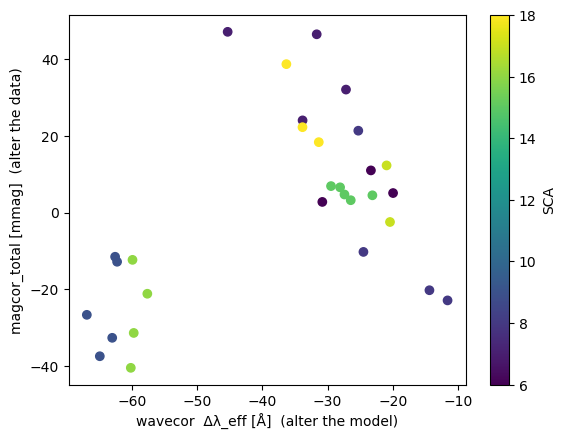

In [2]:
import matplotlib.pyplot as plt
plt.scatter(tbl.wavecor, 1e3*tbl.magcor_total, c=tbl.sca)
plt.xlabel("wavecor  Δλ_eff [Å]  (alter the model)")
plt.ylabel("magcor_total [mmag]  (alter the data)")
plt.colorbar(label="SCA"); plt.show()

In [3]:
def mjd_ice_thickness(mjd, rate=50/4.60, period=20.0, epoch0=61295.0):
    return rate * ((mjd - epoch0) % period)     # nm; steady growth, decon every 20 d

tbl = magcor_table(spec, filters, ice, reference_sca=2,
                   ice_thickness_nm=lambda r: mjd_ice_thickness(r.mjd))
print(tbl[["cid","band","sca","mjd","ice_thickness_nm","magcor_shift","magcor_ice","magcor_total","wavecor"]].round(4).head(12))

        cid  band  sca         mjd  ice_thickness_nm  magcor_shift  \
0   2747770  F129    9  62630.0057          163.1054       -0.0044   
1   2747770  F087   18  62640.8838           63.9543        0.0019   
2   2747770  F106   15  62651.1060          175.0652        0.0001   
3   2747770  F087    7  62662.0101           76.1967        0.0063   
4   2747770  F129   16  62673.9263          205.7207       -0.0177   
5   2747770  F106    6  62683.5176           92.5826        0.0047   
6   2747770  F129    9  62692.7996          193.4739       -0.0153   
7   2747770  F087   18  62701.4849           70.4880        0.0191   
8    263515  F087    7  62256.2937           14.0620        0.0105   
9    263515  F106    6  62266.4949          124.9446       -0.0032   
10   263515  F106   15  62315.6060            6.5870        0.0059   
11   263515  F129   16  62336.1898           12.9326        0.0097   

    magcor_ice  magcor_total  wavecor  
0      -0.0209       -0.0263 -66.9475  
1       0

In [4]:
import pandas as pd
from handshaker import DEFAULT_GRID, get_filter
from handshaker.synphot import effective_wavelength_on_grid
g = DEFAULT_GRID
filters = get_filter("rujuta",
    root="/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/handshaker/ROMAN_FILTERS")

def wavecor_table(bands, scas=range(1,19), ref=2, flux=None):   # flat-weighted (flux=None)
    rows = []
    for b in bands:
        lam_ref = effective_wavelength_on_grid(g, filters.shifted(b, ref).regrid(g), flux)
        for s in scas:
            lam = effective_wavelength_on_grid(g, filters.shifted(b, s).regrid(g), flux)
            rows.append({"band": b, "sca": s, "wavecor": lam - lam_ref})
    return pd.DataFrame(rows)

# your truth for J129 (handshaker band F129), codes B..J = SCA 1..9
truth = {1:5.299038, 2:0.0, 3:-27.302776, 4:-15.791303, 5:-16.798229,
         6:-41.325814, 7:-62.099046, 8:-53.655418, 9:-67.962877}
wc = wavecor_table(["F129"])
wc["truth"] = wc.sca.map(truth)
wc["diff"]  = wc.wavecor - wc.truth
print(wc[wc.sca <= 9].round(3).to_string(index=False))

# does SCA 10..18 reproduce its paired SCA (kcor pairs 1&10, 2&11, ... 9&16)?
pairs = {10:1, 11:2, 12:3, 14:4, 13:5, 15:6, 18:7, 17:8, 16:9}
wc["paired_truth"] = wc.sca.map(lambda s: truth.get(pairs.get(s)))
print(wc[wc.sca > 9][["band","sca","wavecor","paired_truth"]].round(3).to_string(index=False))

band  sca  wavecor   truth   diff
F129    1    6.319   5.299  1.020
F129    2    0.000   0.000  0.000
F129    3  -27.148 -27.303  0.155
F129    4  -19.157 -15.791 -3.366
F129    5  -21.033 -16.798 -4.235
F129    6  -42.693 -41.326 -1.367
F129    7  -70.160 -62.099 -8.061
F129    8  -61.499 -53.655 -7.843
F129    9  -73.233 -67.963 -5.270
band  sca  wavecor  paired_truth
F129   10    7.182         5.299
F129   11    1.032         0.000
F129   12  -26.020       -27.303
F129   13  -15.199       -16.798
F129   14  -17.220       -15.791
F129   15  -39.189       -41.326
F129   16  -64.475       -67.963
F129   17  -55.662       -53.655
F129   18  -67.546       -62.099


In [5]:
import os, numpy as np
from handshaker.sed import FixedSED

ph, wv, fl = np.loadtxt(os.path.join(os.environ["SNDATA_ROOT"], "snsed", "Hsiao07.dat"), unpack=True)
m = np.isclose(ph, ph[np.argmin(abs(ph))])          # phase closest to 0 (peak)
hsiao_flux = g.regrid(wv[m], fl[m])                 # weight by Hsiao07 at peak

wc = wavecor_table(["F129"], flux=hsiao_flux)       # your inline wavecor_table takes flux=
wc["truth"] = wc.sca.map(truth); wc["diff"] = wc.wavecor - wc.truth
print(wc[wc.sca <= 9].round(3).to_string(index=False))

band  sca  wavecor   truth   diff
F129    1    5.696   5.299  0.397
F129    2    0.000   0.000  0.000
F129    3  -24.497 -27.303  2.806
F129    4  -17.290 -15.791 -1.499
F129    5  -18.983 -16.798 -2.185
F129    6  -38.517 -41.326  2.809
F129    7  -63.273 -62.099 -1.174
F129    8  -55.469 -53.655 -1.813
F129    9  -66.051 -67.963  1.912


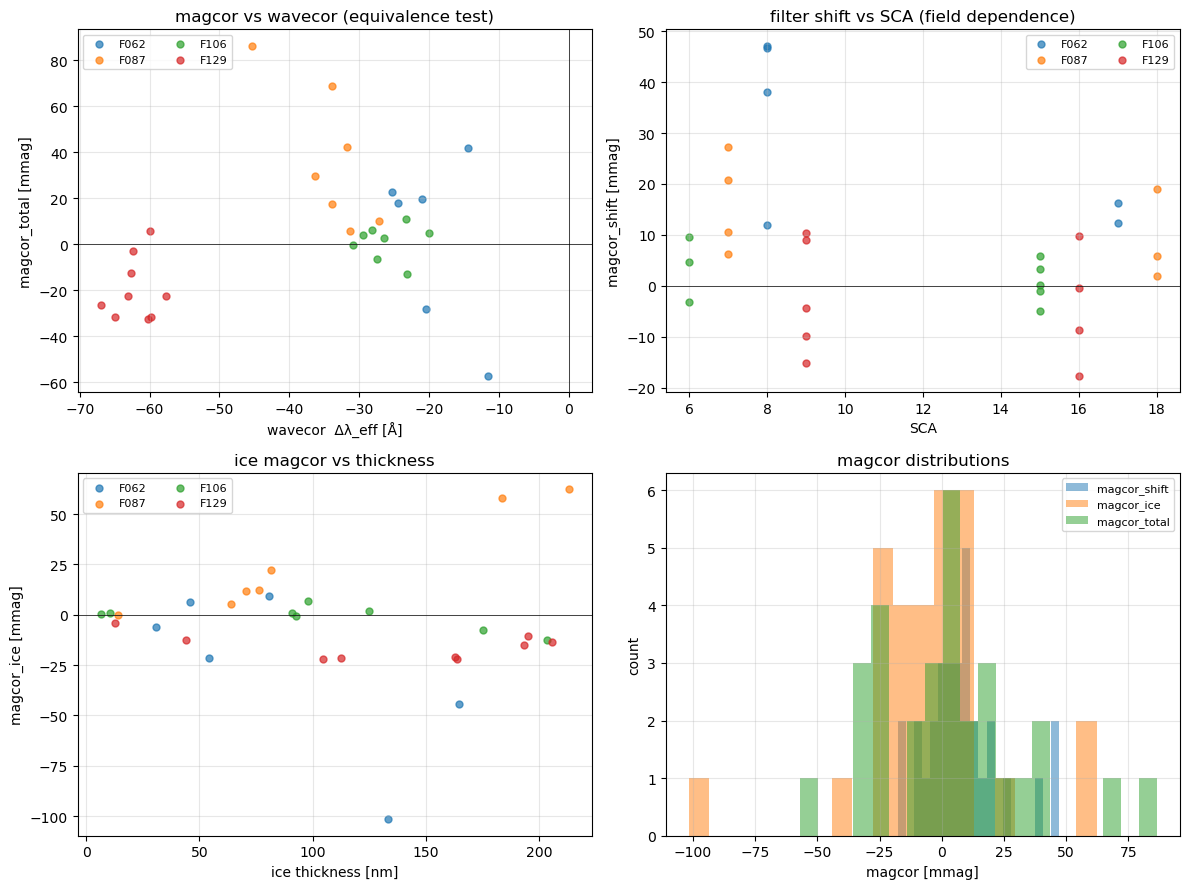

In [6]:
from handshaker import load_modelspec, magcor_table, get_filter, get_ice_model, mjd_ice_thickness
from handshaker.plots import plot_magcor

spec = load_modelspec("/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/handshaker/tests/CODETEST_HANDSHAKER.root", tree="MODELSPEC")
filters = get_filter("rujuta", root="/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/handshaker/ROMAN_FILTERS")
ice = get_ice_model("released")

tbl = magcor_table(spec, filters, ice, reference_sca=2,
                   ice_thickness_nm=lambda r: mjd_ice_thickness(r.mjd))

fig = plot_magcor(tbl, path="magcor_diag.png")   # saves + returns fig; shows inline too

In [7]:
avg = tbl.groupby(["band","sca"])[["magcor_shift","magcor_ice","magcor_total"]].mean()
print(avg.round(4))

          magcor_shift  magcor_ice  magcor_total
band sca                                        
F062 8          0.0360     -0.0300        0.0065
     17         0.0142     -0.0189       -0.0042
F087 7          0.0162      0.0232        0.0391
     18         0.0090      0.0263        0.0348
F106 6          0.0037      0.0007        0.0051
     15         0.0007     -0.0024       -0.0012
F129 9         -0.0020     -0.0163       -0.0191
     16        -0.0043     -0.0153       -0.0202


    band  sca  magcor_total  magcorwave_total  resid_total  resid_ice  \
0   F129    9       -0.0263           -0.0115      -0.0148    -0.0188   
1   F087   18        0.0059           -0.0028       0.0088     0.0059   
2   F106   15       -0.0065           -0.0004      -0.0061    -0.0104   
3   F087    7        0.0175            0.0030       0.0145     0.0118   
4   F129   16       -0.0324           -0.0285      -0.0039    -0.0073   
5   F106    6        0.0048            0.0003       0.0045     0.0011   
6   F129    9       -0.0316           -0.0237      -0.0078    -0.0099   
7   F087   18        0.0296            0.0214       0.0082     0.0064   
8   F087    7        0.0103            0.0060       0.0044    -0.0007   
9   F106    6       -0.0002           -0.0020       0.0018    -0.0034   
10  F106   15        0.0064            0.0033       0.0031     0.0006   
11  F129   16        0.0058            0.0046       0.0012    -0.0040   
12  F129    9       -0.0123            0.0049      

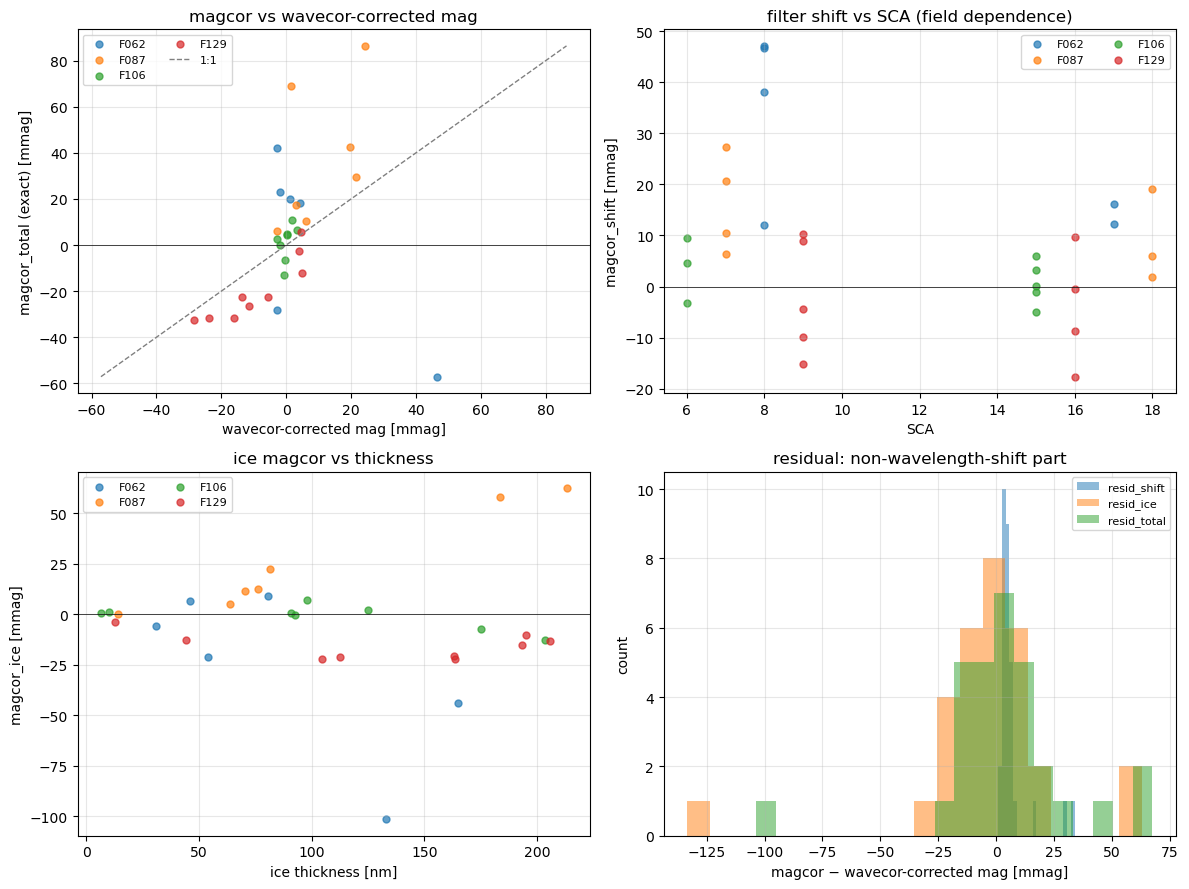

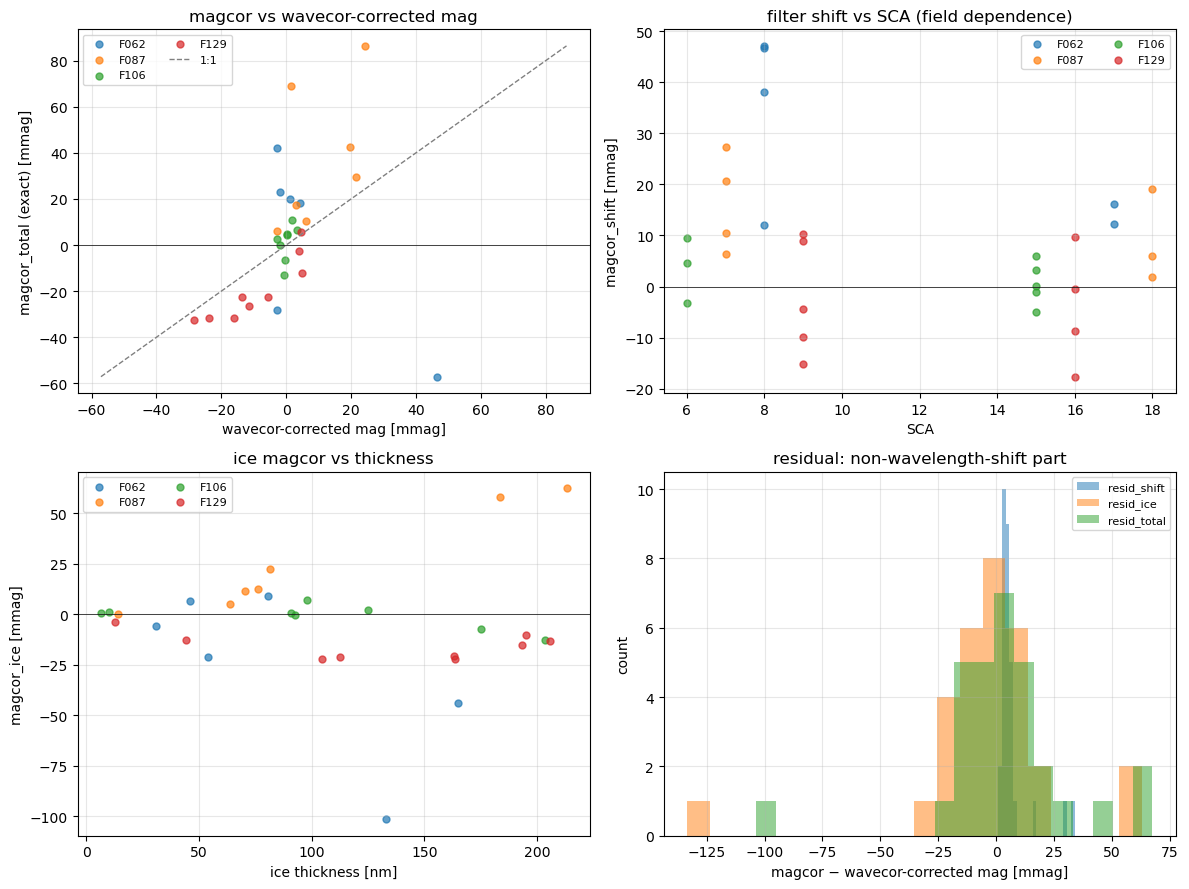

In [1]:
from handshaker import load_modelspec, magcor_table, get_filter, get_ice_model, mjd_ice_thickness
from handshaker.plots import plot_magcor

spec = load_modelspec("/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/handshaker/tests/CODETEST_HANDSHAKER.root", tree="MODELSPEC")
filters = get_filter("rujuta", root="/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/handshaker/ROMAN_FILTERS")

ice = get_ice_model("released")

tbl = magcor_table(spec, filters, ice, reference_sca=2,
                   ice_thickness_nm=lambda r: mjd_ice_thickness(r.mjd))
                   
print(tbl[["band","sca","magcor_total","magcorwave_total","resid_total","resid_ice","resid_shift"]].round(4))

plot_magcor(tbl, path="magcor_diag.png")   # panel 1: magcor vs wavecor-corrected mag; panel 4: residual

In [3]:
for b, g in spec.groupby("band"):
    w = g.sed.iloc[0].wave
    nom = filters.nominal(b)
    supp = nom.wave[nom.thru > 0.01 * nom.thru.max()]
    print(f"{b}: SED {w.min():.0f}-{w.max():.0f} Å   band {supp.min():.0f}-{supp.max():.0f} Å   "
          f"{'OK' if w.min() <= supp.min() and w.max() >= supp.max() else '*** SED TRUNCATED ***'}")

F062: SED 4590-7960 Å   band 4700-7800 Å   OK
F087: SED 7240-10210 Å   band 7400-10000 Å   OK
F106: SED 8840-12460 Å   band 9050-12200 Å   OK
F129: SED 10790-15210 Å   band 11050-14900 Å   OK


In [4]:
import numpy as np
print(tbl.loc[tbl.magcor_ice.abs().sort_values(ascending=False).index[:5],
      ["cid","band","sca","mjd","trest","ice_thickness_nm","magcor_ice","magcor_total","resid_ice"]].round(3))

        cid  band  sca        mjd   trest  ice_thickness_nm  magcor_ice  \
28  2023923  F062    8  62367.250  43.548           133.148      -0.102   
18  2356175  F087   18  62194.602  18.289           213.064       0.062   
29  2023923  F087    7  62371.903  46.134           183.727       0.058   
23  2023923  F062   17  62270.154 -10.396           164.722      -0.044   
14   263515  F087    7  62382.514  43.628            81.672       0.022   

    magcor_total  resid_ice  
28        -0.057     -0.134  
18         0.069      0.063  
29         0.086      0.062  
23        -0.028     -0.034  
14         0.042      0.017  


In [2]:
from handshaker import load_modelspec, magcor_table, get_filter, get_ice_model, mjd_ice_thickness

filters = get_filter("rujuta", root="/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/handshaker/ROMAN_FILTERS")
thk = lambda r: mjd_ice_thickness(r.mjd)

ice_true = get_ice_model("released")                             # true ice model
ice_poly = get_ice_model("polyfit", filters=filters, order=5)    # polynomial ice model

tbl_true = magcor_table(spec, filters, ice_true, reference_sca=2, ice_thickness_nm=thk)
tbl_poly = magcor_table(spec, filters, ice_poly, reference_sca=2, ice_thickness_nm=thk)

# three ways to correct ice, and each method's error vs the truth
cmp = tbl_true[["cid","band","sca","ice_thickness_nm"]].copy()
cmp["ice_true"]  = tbl_true["magcor_ice"]                 # truth (full ice model)
cmp["ice_poly"]  = tbl_poly["magcor_ice"]                 # polynomial ice
cmp["ice_wave"]  = tbl_true["magcorwave_ice"]             # wavelength-shift (wavecor)
cmp["err_poly"]  = 1e3 * (cmp.ice_poly - cmp.ice_true)    # mmag
cmp["err_wave"]  = 1e3 * (cmp.ice_wave - cmp.ice_true)    # mmag
print(cmp.round(3).to_string(index=False))

# per-band: how badly each method misses the true ice correction (RMS mmag)
print("\nRMS error vs true ice [mmag], by band:")
print(cmp.groupby("band")[["err_poly","err_wave"]].apply(lambda g: (g**2).mean()**0.5).round(3))


    cid band  sca  ice_thickness_nm  ice_true  ice_poly  ice_wave  err_poly  err_wave
2747770 F129    9           163.105    -0.021    -0.021    -0.002     0.004    18.806
2747770 F087   18            63.954     0.005     0.005    -0.001     0.006    -5.947
2747770 F106   15           175.065    -0.008    -0.008     0.003    -0.004    10.373
2747770 F087    7            76.197     0.012     0.012     0.001     0.000   -11.789
2747770 F129   16           205.721    -0.014    -0.014    -0.006     0.009     7.306
2747770 F106    6            92.583    -0.000    -0.000    -0.002     0.001    -1.096
2747770 F129    9           193.474    -0.015    -0.015    -0.005     0.004     9.886
2747770 F087   18            70.488     0.012     0.012     0.005    -0.002    -6.371
 263515 F087    7            14.062     0.000     0.000     0.001     0.004     0.680
 263515 F106    6           124.945     0.002     0.002     0.005    -0.007     3.358
 263515 F106   15             6.587     0.000     0.00

In [3]:
cmp = tbl_true[["cid","band","sca","ice_thickness_nm"]].copy()
cmp["ice_true"] = tbl_true["magcor_ice"]                          # truth (full ice model)
cmp["ice_poly"] = tbl_poly["magcor_ice"]                          # polynomial ice
cmp["err_poly"] = 1e3 * (cmp.ice_poly - cmp.ice_true)            # mmag: polyfit error
cmp["err_wave"] = -1e3 * tbl_true["resid_ice"]                    # mmag: wavecor error (= -(magcor-magcorwave))
print(cmp.round(3).to_string(index=False))

print("\nRMS error vs true ice [mmag], by band:")
print(cmp.groupby("band")[["err_poly","err_wave"]].apply(lambda g: (g**2).mean()**0.5).round(3))

    cid band  sca  ice_thickness_nm  ice_true  ice_poly  err_poly  err_wave
2747770 F129    9           163.105    -0.021    -0.021     0.004    18.806
2747770 F087   18            63.954     0.005     0.005     0.006    -5.947
2747770 F106   15           175.065    -0.008    -0.008    -0.004    10.373
2747770 F087    7            76.197     0.012     0.012     0.000   -11.789
2747770 F129   16           205.721    -0.014    -0.014     0.009     7.306
2747770 F106    6            92.583    -0.000    -0.000     0.001    -1.096
2747770 F129    9           193.474    -0.015    -0.015     0.004     9.886
2747770 F087   18            70.488     0.012     0.012    -0.002    -6.371
 263515 F087    7            14.062     0.000     0.000     0.004     0.680
 263515 F106    6           124.945     0.002     0.002    -0.007     3.358
 263515 F106   15             6.587     0.000     0.000     0.001    -0.573
 263515 F129   16            12.933    -0.004    -0.004     0.000     3.984
 263515 F129

In [1]:
from handshaker import get_filter, get_ice_model, write_snana_filters
bands = ["F062","F087","F106","F129","F158","F184"]
f = get_filter("rujuta", root="/project2/rkessler/SURVEYS/ROMAN/USERS/rpurohit/handshaker/ROMAN_FILTERS")
ice = get_ice_model("released")

write_snana_filters(f, bands, "FILT_ref", sca=2)                                  # reference: SCA2, no ice
write_snana_filters(f, bands, "FILT_ice", sca=2, ice_model=ice, thickness_nm=150) # perturbed: SCA2 × ice@150nm

['FILT_ice/ROMAN_F062.dat',
 'FILT_ice/ROMAN_F087.dat',
 'FILT_ice/ROMAN_F106.dat',
 'FILT_ice/ROMAN_F129.dat',
 'FILT_ice/ROMAN_F158.dat',
 'FILT_ice/ROMAN_F184.dat']

In [2]:
from handshaker import load_lcplot, empirical_magcor, compare_to_empirical, load_modelspec, magcor_table, mjd_ice_thickness
emp  = empirical_magcor(load_lcplot("out_ref.LCPLOT.TEXT"), load_lcplot("out_ice.LCPLOT.TEXT"), dataflag="DATAFLAG")
spec = load_modelspec("CODETEST_HANDSHAKER.root", tree="MODELSPEC")
pred = magcor_table(spec, f, ice, reference_sca=2, ice_thickness_nm=150.0)   # same fixed 150 nm
merged, stats = compare_to_empirical(emp, pred, pred_col="magcor_ice")
print(stats)

FileNotFoundError: [Errno 2] No such file or directory: 'out_ref.LCPLOT.TEXT'

In [ ]:
## VALIDATE

from handshaker import (load_lcplot, load_modelspec, magcor_table, get_filter,
                        get_ice_model, mjd_ice_thickness, empirical_magcor, compare_to_empirical)
from handshaker.validate import plot_validation

ref  = load_lcplot("CODETEST_HANDSHAKER_S1.LCPLOT.TEXT")   # nominal / SCA2 / no effect
pert = load_lcplot("CODETEST_HANDSHAKER_S2.LCPLOT.TEXT")   # true filter (× ice)
emp  = empirical_magcor(ref, pert, dataflag="DATAFLAG")    # -2.5 log(F_pert/F_ref)

spec    = load_modelspec(".../CODETEST_HANDSHAKER.root", tree="MODELSPEC")   # SED_ref
filters = get_filter("rujuta", root=".../ROMAN_FILTERS")
pred    = magcor_table(spec, filters, get_ice_model("released"), reference_sca=2,
                       ice_thickness_nm=lambda r: mjd_ice_thickness(r.mjd))

merged, stats = compare_to_empirical(emp, pred, pred_col="magcor_total")
print(stats)                                   # {'residual_mean':…, 'slope':…, 'correlation':…}
plot_validation(merged, stats, path="validation.png")
